# 7 - Compare, Evaluate, Export

## 1. Install dan setup

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib openpyxl

# =========================================================
# Helper: input fleksibel untuk Google Colab
# =========================================================
from pathlib import Path
import os, re, shutil, json, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

BASE_DIR = Path("/content")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
EDA_DIR = OUTPUT_DIR / "eda"
SENTIMENT_DIR = OUTPUT_DIR / "sentiment"
MODEL_DIR = OUTPUT_DIR / "models"
FINAL_DIR = OUTPUT_DIR / "final"

for d in [DATA_DIR, OUTPUT_DIR, EDA_DIR, SENTIMENT_DIR, MODEL_DIR, FINAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def upload_file_colab(prompt="Upload file CSV"):
    """Upload file di Google Colab dan return Path file pertama."""
    from google.colab import files
    print(prompt)
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("Tidak ada file yang di-upload.")
    filename = list(uploaded.keys())[0]
    return Path(filename)


def find_or_upload(candidates, upload_prompt):
    """
    Cari file dari daftar kandidat. Kalau tidak ada, minta upload.
    Cocok untuk Colab: bisa lanjut dari file hasil notebook sebelumnya.
    """
    for p in candidates:
        p = Path(p)
        if p.exists():
            print(f"File ditemukan: {p}")
            return p
    return upload_file_colab(upload_prompt)


def normalize_sentiment_label(label):
    """Samakan label menjadi Positive / Neutral / Negative."""
    if pd.isna(label):
        return np.nan
    text = str(label).strip().lower()

    positive_values = {"positive", "positif", "pos", "1", "label_0"}
    neutral_values = {"neutral", "netral", "neu", "0", "label_1"}
    negative_values = {"negative", "negatif", "neg", "-1", "label_2"}

    if text in positive_values:
        return "Positive"
    if text in neutral_values:
        return "Neutral"
    if text in negative_values:
        return "Negative"
    return np.nan


def standardize_dataframe(df):
    """
    Standarisasi kolom dari hasil preprocessing 2a.
    File sumber biasanya punya: Link, Judul, Isi Berita, Status, Tag, Sentimen, Penerbit,
    final_text_clean, final_text_stemmed, jumlah_token_before_sw, jumlah_token_after_sw.
    """
    df = df.copy()

    rename_map = {
        "Link": "source_url",
        "Judul": "title",
        "Isi Berita": "content",
        "Status": "scrape_status",
        "Tag": "tag",
        "Sentimen": "sentiment_original",
        "Sentiment": "sentiment_original",
        "Penerbit": "publisher",
        "Tanggal": "published_date"
    }

    for old, new in rename_map.items():
        if old in df.columns and new not in df.columns:
            df[new] = df[old]

    # Label asli/manual untuk evaluasi
    if "label_true" not in df.columns:
        if "sentiment_original" in df.columns:
            df["label_true"] = df["sentiment_original"].apply(normalize_sentiment_label)
        else:
            df["label_true"] = np.nan

    # Kolom teks fallback
    if "final_text_clean" not in df.columns:
        if "content" in df.columns:
            df["final_text_clean"] = df["content"].fillna("").astype(str).str.lower()
        else:
            raise KeyError("Tidak ditemukan kolom final_text_clean atau content/Isi Berita.")

    if "final_text_stemmed" not in df.columns:
        df["final_text_stemmed"] = df["final_text_clean"]

    # Token count fallback
    if "jumlah_token_before_sw" not in df.columns:
        df["jumlah_token_before_sw"] = df["final_text_clean"].fillna("").astype(str).str.split().apply(len)
    if "jumlah_token_after_sw" not in df.columns:
        df["jumlah_token_after_sw"] = df["final_text_stemmed"].fillna("").astype(str).str.split().apply(len)

    # Filter success kalau kolom status ada
    if "scrape_status" in df.columns:
        success_mask = df["scrape_status"].astype(str).str.lower().eq("success")
        if success_mask.sum() > 0:
            df = df[success_mask].copy()

    # Buang teks kosong
    df["final_text_clean"] = df["final_text_clean"].fillna("").astype(str)
    df["final_text_stemmed"] = df["final_text_stemmed"].fillna("").astype(str)
    df = df[df["final_text_clean"].str.strip().ne("")].copy()
    df = df.reset_index(drop=True)

    return df


def load_after_2a_csv(path):
    """Load CSV hasil preprocessing 2a dengan fallback encoding."""
    path = Path(path)
    try:
        df = pd.read_csv(path)
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding="latin-1")
    return standardize_dataframe(df)


def safe_display(obj, n=5):
    try:
        display(obj)
    except Exception:
        print(obj.head(n) if hasattr(obj, "head") else obj)


## 2. Input data semua metode

In [2]:

INPUT_PATH = find_or_upload(
    candidates=[
        SENTIMENT_DIR / "hasil_all_methods_sentiment.csv",
        "/content/hasil_all_methods_sentiment.csv",
        SENTIMENT_DIR / "hasil_textblob_logreg_sentiment.csv",
        "/content/hasil_textblob_logreg_sentiment.csv",
    ],
    upload_prompt="Upload hasil_all_methods_sentiment.csv"
)

df = load_after_2a_csv(INPUT_PATH)
print("Input:", INPUT_PATH)
print("Shape:", df.shape)
print("Kolom prediksi tersedia:")
for c in ["textblob_sentiment", "logreg_sentiment", "indobert_sentiment"]:
    print(c, "=", c in df.columns)
safe_display(df.head(3))


Upload hasil_all_methods_sentiment.csv


Saving hasil_all_methods_sentiment.csv to hasil_all_methods_sentiment.csv
Input: hasil_all_methods_sentiment.csv
Shape: (1829, 31)
Kolom prediksi tersedia:
textblob_sentiment = True
logreg_sentiment = True
indobert_sentiment = True


,Link,Judul,Isi Berita,Status,Tag,Sentimen,Penerbit,final_text_clean,final_text_stemmed,jumlah_token_before_sw,...,textblob_sentiment,logreg_sentiment,split,logreg_prob_Negative,logreg_prob_Neutral,logreg_prob_Positive,logreg_confidence,indobert_raw_label,indobert_score,indobert_sentiment
0,https://money.kompas.com/image/2017/10/03/1815...,Foto : CSR Pertamina Lubricants Kini Fokus ke ...,Diskusi mengenai CSR di industri pelumas berta...,success,Ekonomi,Neutral,Kompas,diskusi mengenai csr industri pelumas bertajuk...,diskusi kena csr industri lumas tajuk cari for...,16,...,Neutral,Neutral,train,0.166593,0.518138,0.315269,0.518138,LABEL_1,0.995060,Neutral
1,https://money.kompas.com/read/2016/06/06/14280...,"Gandeng Dua Bank, Pertamina Lubricants Yakin P...","JAKARTA, KOMPAS.com - Anak perusahaan Pertamin...",success,Kecelakaan Kerja,Positive,Kompas,jakarta kompas com anak perusahaan pertamina y...,anak usaha pertamina pertamina lubricants gand...,130,...,Neutral,Positive,test,0.116579,0.331690,0.551732,0.551732,LABEL_0,0.806849,Positive
2,https://money.kompas.com/read/2017/02/03/12195...,"Dua Pucuk Pimpinan Pertamina Dicopot, Yenni An...","JAKARTA, KOMPAS.com — Pasca-pencopotan dua puc...",success,Migas,Positive,Kompas,jakarta kompas com pasca pencopotan dua pucuk ...,pasca copot pucuk pimpin pertamina menteri bad...,145,...,Neutral,Neutral,train,0.136259,0.479430,0.384311,0.479430,LABEL_1,0.795107,Neutral


## 3. Distribusi dan agreement antar metode

Distribusi prediksi:


,method,sentiment,jumlah
0,TextBlob,Positive,513
1,TextBlob,Neutral,1090
2,TextBlob,Negative,226
3,TF-IDF + Logistic Regression,Positive,768
4,TF-IDF + Logistic Regression,Neutral,618
5,TF-IDF + Logistic Regression,Negative,443
6,IndoBERT,Positive,515
7,IndoBERT,Neutral,1002
8,IndoBERT,Negative,312


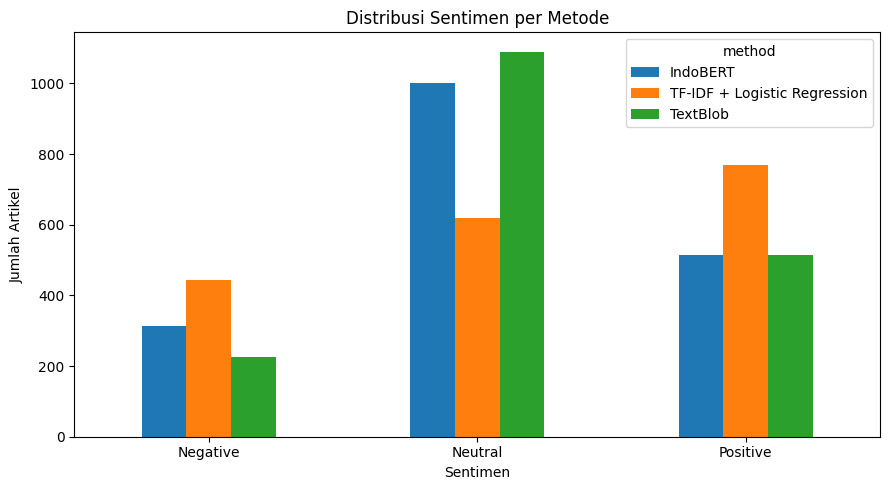

Agreement antar metode:


,comparison,agreement_count,agreement_percent
0,TextBlob vs TF-IDF + Logistic Regression,634,34.66
1,TextBlob vs IndoBERT,852,46.58
2,TF-IDF + Logistic Regression vs IndoBERT,901,49.26
3,Semua metode sama,368,20.12


In [3]:

import matplotlib.pyplot as plt

method_cols = {
    "TextBlob": "textblob_sentiment",
    "TF-IDF + Logistic Regression": "logreg_sentiment",
    "IndoBERT": "indobert_sentiment",
}
method_cols = {k:v for k,v in method_cols.items() if v in df.columns}

records = []
for method, col in method_cols.items():
    counts = df[col].value_counts().reindex(["Positive", "Neutral", "Negative"], fill_value=0)
    for sentiment, jumlah in counts.items():
        records.append({"method": method, "sentiment": sentiment, "jumlah": int(jumlah)})

distribution_df = pd.DataFrame(records)
print("Distribusi prediksi:")
safe_display(distribution_df)

# Plot distribusi
if len(distribution_df) > 0:
    pivot_dist = distribution_df.pivot(index="sentiment", columns="method", values="jumlah")
    ax = pivot_dist.plot(kind="bar", figsize=(9,5))
    plt.title("Distribusi Sentimen per Metode")
    plt.xlabel("Sentimen")
    plt.ylabel("Jumlah Artikel")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FINAL_DIR / "distribusi_sentimen_per_metode.png", dpi=150)
    plt.show()

# Agreement
agreement_records = []
pairs = [
    ("TextBlob", "textblob_sentiment", "TF-IDF + Logistic Regression", "logreg_sentiment"),
    ("TextBlob", "textblob_sentiment", "IndoBERT", "indobert_sentiment"),
    ("TF-IDF + Logistic Regression", "logreg_sentiment", "IndoBERT", "indobert_sentiment"),
]

for a_name, a_col, b_name, b_col in pairs:
    if a_col in df.columns and b_col in df.columns:
        agree = df[a_col] == df[b_col]
        agreement_records.append({
            "comparison": f"{a_name} vs {b_name}",
            "agreement_count": int(agree.sum()),
            "agreement_percent": round(float(agree.mean() * 100), 2)
        })

if all(c in df.columns for c in ["textblob_sentiment", "logreg_sentiment", "indobert_sentiment"]):
    df["all_methods_agree"] = (
        (df["textblob_sentiment"] == df["logreg_sentiment"]) &
        (df["textblob_sentiment"] == df["indobert_sentiment"])
    )
    agreement_records.append({
        "comparison": "Semua metode sama",
        "agreement_count": int(df["all_methods_agree"].sum()),
        "agreement_percent": round(float(df["all_methods_agree"].mean() * 100), 2)
    })

agreement_df = pd.DataFrame(agreement_records)
print("Agreement antar metode:")
safe_display(agreement_df)


## 4. Evaluasi dengan label manual/asli

In [4]:

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

metrics = []
confusion_matrices = {}
reports = {}

eval_df = df.dropna(subset=["label_true"]).copy()

if len(eval_df) == 0:
    print("Tidak ada label_true. Evaluasi metrik tidak bisa dilakukan.")
else:
    print("Jumlah data evaluasi:", len(eval_df))
    for method, col in method_cols.items():
        temp = eval_df.dropna(subset=[col]).copy()
        if len(temp) == 0:
            continue
        y_true = temp["label_true"]
        y_pred = temp[col]
        acc = accuracy_score(y_true, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
        metrics.append({
            "method": method,
            "accuracy": round(acc, 4),
            "precision_weighted": round(precision, 4),
            "recall_weighted": round(recall, 4),
            "f1_weighted": round(f1, 4),
            "jumlah_data_eval": len(temp)
        })
        cm = pd.DataFrame(
            confusion_matrix(y_true, y_pred, labels=["Positive", "Neutral", "Negative"]),
            index=["Actual_Positive", "Actual_Neutral", "Actual_Negative"],
            columns=["Pred_Positive", "Pred_Neutral", "Pred_Negative"]
        )
        confusion_matrices[method] = cm
        reports[method] = classification_report(y_true, y_pred, labels=["Positive", "Neutral", "Negative"], zero_division=0, output_dict=True)
        print(f"\nClassification Report - {method}")
        print(classification_report(y_true, y_pred, labels=["Positive", "Neutral", "Negative"], zero_division=0))
        safe_display(cm)

metrics_df = pd.DataFrame(metrics).sort_values("f1_weighted", ascending=False) if metrics else pd.DataFrame()
print("Ringkasan metrik:")
safe_display(metrics_df)


Jumlah data evaluasi: 1829

Classification Report - TextBlob
              precision    recall  f1-score   support

    Positive       0.45      0.30      0.36       765
     Neutral       0.35      0.59      0.44       657
    Negative       0.19      0.10      0.13       407

    accuracy                           0.36      1829
   macro avg       0.33      0.33      0.31      1829
weighted avg       0.36      0.36      0.34      1829



,Pred_Positive,Pred_Neutral,Pred_Negative
Actual_Positive,233,424,108
Actual_Neutral,196,385,76
Actual_Negative,84,281,42



Classification Report - TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    Positive       0.86      0.87      0.87       765
     Neutral       0.85      0.80      0.82       657
    Negative       0.82      0.90      0.86       407

    accuracy                           0.85      1829
   macro avg       0.85      0.85      0.85      1829
weighted avg       0.85      0.85      0.85      1829



,Pred_Positive,Pred_Neutral,Pred_Negative
Actual_Positive,664,70,31
Actual_Neutral,85,525,47
Actual_Negative,19,23,365



Classification Report - IndoBERT
              precision    recall  f1-score   support

    Positive       0.65      0.44      0.52       765
     Neutral       0.38      0.58      0.46       657
    Negative       0.49      0.38      0.43       407

    accuracy                           0.47      1829
   macro avg       0.51      0.46      0.47      1829
weighted avg       0.52      0.47      0.48      1829



,Pred_Positive,Pred_Neutral,Pred_Negative
Actual_Positive,334,382,49
Actual_Neutral,168,380,109
Actual_Negative,13,240,154


Ringkasan metrik:


,method,accuracy,precision_weighted,recall_weighted,f1_weighted,jumlah_data_eval
1,TF-IDF + Logistic Regression,0.8496,0.8501,0.8496,0.8493,1829
2,IndoBERT,0.4746,0.5173,0.4746,0.4782,1829
0,TextBlob,0.3609,0.3582,0.3609,0.3404,1829


## 5. Contoh artikel yang berbeda prediksi

In [5]:

review_cols = [
    "source_url", "title", "tag", "publisher", "sentiment_original", "label_true",
    "textblob_sentiment", "logreg_sentiment", "indobert_sentiment",
    "textblob_polarity", "logreg_confidence", "indobert_score",
    "final_text_clean"
]
review_cols = [c for c in review_cols if c in df.columns]

if all(c in df.columns for c in ["textblob_sentiment", "logreg_sentiment", "indobert_sentiment"]):
    different_df = df[~(
        (df["textblob_sentiment"] == df["logreg_sentiment"]) &
        (df["textblob_sentiment"] == df["indobert_sentiment"])
    )][review_cols].copy()
else:
    different_df = df[review_cols].copy()

print("Jumlah artikel dengan prediksi berbeda:", len(different_df))
safe_display(different_df.head(20))


Jumlah artikel dengan prediksi berbeda: 1461


,source_url,title,tag,publisher,sentiment_original,label_true,textblob_sentiment,logreg_sentiment,indobert_sentiment,textblob_polarity,logreg_confidence,indobert_score,final_text_clean
1,https://money.kompas.com/read/2016/06/06/14280...,"Gandeng Dua Bank, Pertamina Lubricants Yakin P...",Kecelakaan Kerja,Kompas,Positive,Positive,Neutral,Positive,Positive,0.000000,0.551732,0.806849,jakarta kompas com anak perusahaan pertamina y...
3,https://money.kompas.com/read/2016/05/27/20434...,Ini yang Dilakukan PTKAM untuk Efisiensi 'Oil ...,Gangguan Operasional,Kompas,Positive,Positive,Neutral,Positive,Positive,0.000000,0.555967,0.586893,jakarta kompas com pertamina persero telah mem...
4,https://money.kompas.com/read/2017/03/24/11200...,Ini Tugas Pertama Adiatma Sardjito Sebagai Jub...,Migas,Kompas,Positive,Positive,Neutral,Positive,Positive,0.000000,0.427274,0.464756,jakarta kompas com adiatma sardjito telah resm...
5,https://money.kompas.com/read/2017/01/16/15300...,"Akhirnya, Proyek Kilang Tuban Gunakan Lahan KL...",Migas,Kompas,Positive,Positive,Positive,Positive,Neutral,0.136364,0.566593,0.563465,jakarta kompas com pertamina persero akhirnya ...
6,https://nasional.kompas.com/read/2017/11/03/15...,"Jadi Tersangka Dana Pensiun Pertamina, Edward ...",Hukum,Kompas,Negative,Negative,Neutral,Negative,Neutral,0.000000,0.754137,0.749409,jakarta kompas com penyidik jaksa agung muda p...
7,https://nasional.kompas.com/read/2017/08/16/16...,Viral Video Pertamax dan Pertalite Berwarna Sa...,BBM,Kompas,Neutral,Neutral,Neutral,Neutral,Negative,0.000000,0.673239,0.706556,jakarta kompas com seorang warganet bernama pa...
8,https://otomotif.kompas.com/read/2017/04/21/13...,Spesial Buat Wanita di SPBU Pertamina,BBM,Kompas,Neutral,Neutral,Positive,Neutral,Neutral,0.175000,0.530936,0.421760,jakarta kompasotomotif pertamina persero membe...
9,https://money.kompas.com/image/2017/08/03/0900...,"Foto : Cegah Kepunahan, Pertamina Lestarikan T...",Bisnis,Kompas,Positive,Positive,Neutral,Positive,Neutral,0.000000,0.483399,0.991437,pelepasan indukan tuntong laut oleh tim konser...
10,https://money.kompas.com/read/2016/04/29/19151...,Pertamina Ekspor Perdana Aspal ke Timor Leste,Migas,Kompas,Positive,Positive,Negative,Positive,Positive,-0.075000,0.573632,0.484767,gresik kompas com untuk pertama kalinya pertam...
12,https://money.kompas.com/read/2016/04/11/17345...,Pertamina Menaikkan Ongkos Angkut Minyak Penam...,Migas,Kompas,Positive,Positive,Negative,Positive,Negative,-0.500000,0.461812,0.388803,bojonegoro kompas com pemerintah terus mengupa...


## 6. Export final Excel dan CSV

In [6]:

FINAL_CSV = FINAL_DIR / "hasil_final_perbandingan_sentimen.csv"
FINAL_EXCEL = FINAL_DIR / "hasil_final_perbandingan_sentimen.xlsx"

df.to_csv(FINAL_CSV, index=False)

with pd.ExcelWriter(FINAL_EXCEL, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Prediksi_Per_Artikel", index=False)
    distribution_df.to_excel(writer, sheet_name="Distribusi_Metode", index=False)
    agreement_df.to_excel(writer, sheet_name="Agreement", index=False)
    if not metrics_df.empty:
        metrics_df.to_excel(writer, sheet_name="Evaluasi_Metrik", index=False)
    if len(different_df) > 0:
        different_df.head(500).to_excel(writer, sheet_name="Sample_Beda_Prediksi", index=False)
    for method, cm in confusion_matrices.items():
        cm.to_excel(writer, sheet_name=("CM_" + method.replace(" ", "_"))[:31])

print("Final CSV:", FINAL_CSV)
print("Final Excel:", FINAL_EXCEL)

from google.colab import files
files.download(str(FINAL_EXCEL))


Final CSV: /content/outputs/final/hasil_final_perbandingan_sentimen.csv
Final Excel: /content/outputs/final/hasil_final_perbandingan_sentimen.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>